In [12]:
# 7.1

import numpy as np
from numpy.linalg import inv
from numpy import linalg as la

M = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3,3)
print("M=")
print(M)

det = la.det(M)
print(f"\nDeterminant of M is: {det}")

b = np.array([2,2,-1])
Minv = inv(M)
xyz = Minv@b
print(f"\nSolution: x, y, z = {xyz}")

Mtrans = M.T
print(Minv)
print(Mtrans)
print(f"\nM.MT is not the identity matrix:\n{M@Mtrans}")
print("so it is not orthogonal\n")

Lambda, v = la.eig(M)
print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{v}")

M=
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]

Determinant of M is: 1.0

Solution: x, y, z = [10. -1. -2.]
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

M.MT is not the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
so it is not orthogonal

Lambda =  [ 1.         -4.79128785 -0.20871215]

Eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [5]:
# 7.2

# E = Ez(180-123).Ey(90-27.4).Ez(192.25)

import numpy as np
from numpy.linalg import norm

alpha_deg = 180 - 123     # first rotation around z
beta_deg  = 90 - 27.4     # rotation around new y'
gamma_deg = 192.25        # rotation around new z''

alpha = np.deg2rad(alpha_deg)
beta  = np.deg2rad(beta_deg)
gamma = np.deg2rad(gamma_deg)

def Ez(theta):
    """Rotation about z-axis"""
    return np.array([
        [np.cos(theta), np.sin(theta), 0],
        [-np.sin(theta),np.cos(theta), 0],
        [0, 0, 1]
    ])

def Ey(theta):
    """Rotation about y-axis"""
    return np.array([
        [np.cos(theta), 0, -np.sin(theta)],
        [0, 1, 0],
        [np.sin(theta), 0, np.cos(theta)]
    ])

# Getting the rotation matrix
E = Ez(alpha) @ Ey(beta) @ Ez(gamma)  
print("Composed rotation matrix E:\n", E)

# Checking orthogonality and determinant = 1
orth = E.T @ E
print("\nE^T E:\n", orth)

det = np.linalg.det(E)
print("\nDeterminant of E:", det)

# Computing eigenvalues 
eigvals, eigvecs = np.linalg.eig(E)
print("\nEigenvalues of E:\n", eigvals)

# Galactic pole
a_deg = 192.25
d_deg = 27.4

a = np.deg2rad(a_deg)
d = np.deg2rad(d_deg)

r = np.array([np.cos(a)*np.cos(d), np.sin(a)*np.cos(d), np.sin(d)])
L = norm(r)
v = r.reshape(3,1)

print(f"\nv using eq 7.16 is: \n{v}")
print(f"The norm of v is {L}")

# Rotating v
v2 = E@v
print(f"\nv2 after rotation with E is: \n{v2}")

Composed rotation matrix E:
 [[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

E^T E (should be identity):
 [[ 1.00000000e+00  6.64880766e-19  3.26123487e-17]
 [ 6.64880766e-19  1.00000000e+00 -7.83280728e-17]
 [ 3.26123487e-17 -7.83280728e-17  1.00000000e+00]]

Determinant of E (should be 1): 1.0

Eigenvalues of E:
 [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]

v using eq 7.16 is 
[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
The norm of v is 1.0

v2 after rotation with E is 
[[2.45631360e-17]
 [2.95515309e-17]
 [1.00000000e+00]]


[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331360e+01  2.91867715e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


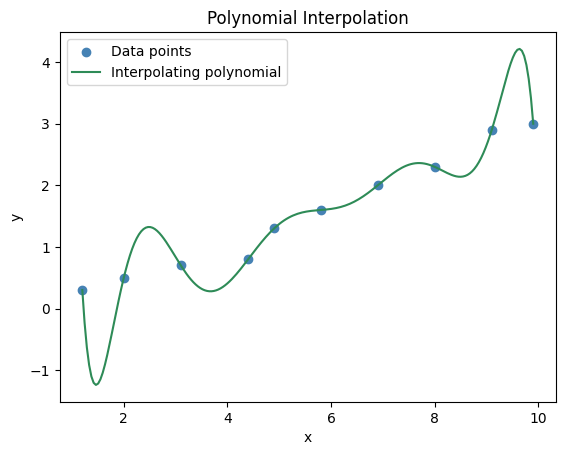

In [4]:
# 7.5

import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        A[i,j] = x[i]**j
        
b = la.solve(A, y)
print(b)

x_plot = np.linspace(min(x), max(x), 200)
y_plot = np.zeros_like(x_plot)

for i in range(len(b)):
    y_plot += b[i] * x_plot**i

# Plot
plt.scatter(x, y, color='steelblue', label='Data points')
plt.plot(x_plot, y_plot, color='seagreen', label='Interpolating polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Polynomial Interpolation')
plt.show()

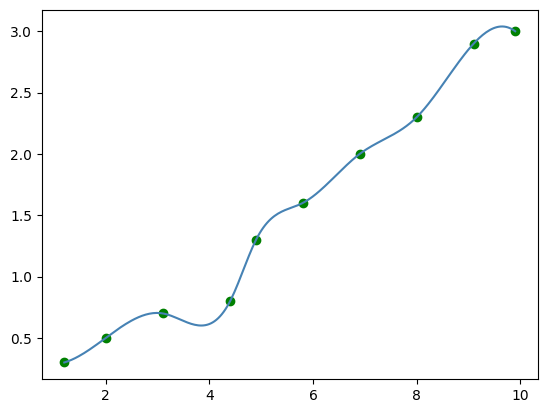

In [12]:
# 7.6 part1

import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip


x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(1.2,9.9,250) # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, color='steelblue')
show()

# Yes looks nicer

In [11]:
# 7.6 part2

import numpy as np
from numpy import linalg as la
from scipy import interpolate as ip

class Interpolation:
    """Class for finding a good interpolation fit""" 
        
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)

        # Linear & cubic
        self.linear_interp = ip.interp1d(self.x, self.y, kind='linear')
        self.quad_interp = ip.interp1d(self.x, self.y, kind='quadratic')
        self.cubic_interp = ip.interp1d(self.x, self.y, kind='cubic')

        # Polynomial 
        n = len(self.x)
        A = np.zeros((n, n))

        for i in range(n):
            for j in range(n):
                A[i, j] = self.x[i]**j

        # Solve for coefficients
        self.coeffs = la.solve(A, self.y)

    def polynomial(self, X):
        X = np.array(X, dtype=float)
        y_val = np.zeros_like(X, dtype=float)

        for i in range(len(self.coeffs)):
            y_val += self.coeffs[i] * X**i

        return y_val

    def interpolate(self, X, method='linear'):
        if method == 'linear':
            return self.linear_interp(X)
        
        elif method == 'quadratic':
            return self.quadratic_interp(X)

        elif method == 'cubic':
            return self.cubic_interp(X)

        elif method == 'polynomial':
            return self.polynomial(X)

        else:
            raise ValueError("Choose 'linear', 'polynomial', 'quadratic' or 'cubic'")
            
a = str(input("Choose a method of interpolation ('linear', 'polynomial', 'quadratic' or 'cubic'): "))
X = float(input("Choose an x between 1.2 and 9.9: "))

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

interp = Interpolation(x, y)
print(interp.interpolate(X, a))

Choose a method of interpolation ('linear', 'polynomial', 'quadratic' or 'cubic'): linear
Choose an x between 1.2 and 9.9: 4.3
0.7923076923076923


In [9]:
# 7.7

def bilinearIP(I, col, row):
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        miu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-miu)*I0 + Lambda*(1-miu)*I1 + miu*(1-Lambda)*I2 + Lambda*miu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]]) 
x=0.2
y=0.7

print(bilinearIP(I,x,y))

2.658


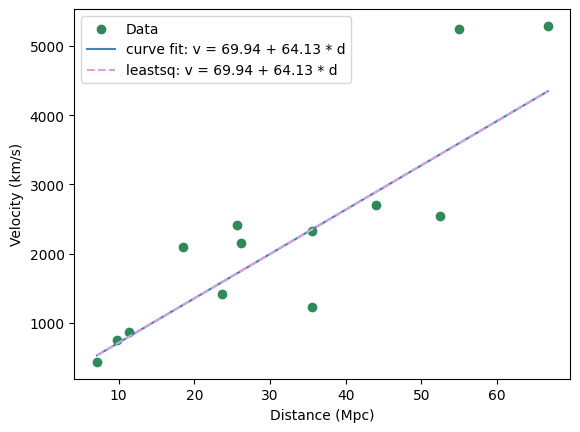

In [9]:
# 7.10

from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit
from scipy.optimize import leastsq
import numpy as np

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]



d = np.array(data[0::4])
v = np.array(data[1::4])
verr = np.array(data[3::4])

def model(x, a, b):
    return a + b * x

# curve_fit with uncertainties
params_cf, pcov = curve_fit(model, d, v, sigma=verr)
a_cf, b_cf = params_cf

# residuals for leastsq
def residuals(params, x, y, sigy):
    a, b = params
    return (y - (a + b * x)) / sigy

# Initial guess
p0 = [0, 70.0]
params_ls, _ = leastsq(residuals, p0, args=(d, v, verr))
a_ls, b_ls = params_ls

# Plot
fig, ax = subplots()
ax.scatter(d, v, color='seagreen', label='Data')
X = np.linspace(d.min(), d.max(), 100)

Y_cf = model(X, a_cf, b_cf)
Y_ls = model(X, a_ls, b_ls)

ax.plot(X, Y_cf, color='steelblue', label=f"curve fit: v = {a_cf:.2f} + {b_cf:.2f} * d")
ax.plot(X, Y_ls, color='plum', linestyle='--', label=f"leastsq: v = {a_ls:.2f} + {b_ls:.2f} * d")

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Velocity (km/s)')
ax.legend()

show()